# 02 — Convolutional VAE Training (The Healer)

A Variational Autoencoder (VAE) learns a compact latent representation that can reconstruct clean images from noisy inputs.

```
Noisy Image -> Encoder -> Latent z -> Decoder -> Reconstructed Clean Image
```

The encoder predicts latent distribution parameters $(\mu, \log\sigma^2)$ and the decoder reconstructs the cleaned output.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from torchinfo import summary

sys.path.append(str(Path('..').resolve()))
torch.manual_seed(42)
np.random.seed(42)

In [2]:
from src.conv_vae import ConvVAE, print_model_summary

with open('../configs/config.yaml', 'r', encoding='utf-8') as file:
    config = yaml.safe_load(file)

vae = ConvVAE(latent_dim=config['vae']['latent_dim'])
print_model_summary(vae)
summary(vae, input_size=(1, 3, 32, 32), depth=3, col_names=('input_size', 'output_size', 'num_params'))

ConvVAE Model Summary
Encoder parameters : 35,793,024
Decoder parameters : 36,548,611
Total parameters   : 72,341,635


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvVAE                                  [1, 3, 32, 32]            [1, 3, 32, 32]            --
├─ConvEncoder: 1-1                       [1, 3, 32, 32]            [1, 256]                  --
│    └─Sequential: 2-1                   [1, 3, 32, 32]            [1, 512, 8, 8]            --
│    │    └─Conv2d: 3-1                  [1, 3, 32, 32]            [1, 128, 16, 16]          6,272
│    │    └─BatchNorm2d: 3-2             [1, 128, 16, 16]          [1, 128, 16, 16]          256
│    │    └─LeakyReLU: 3-3               [1, 128, 16, 16]          [1, 128, 16, 16]          --
│    │    └─Conv2d: 3-4                  [1, 128, 16, 16]          [1, 256, 8, 8]            524,544
│    │    └─BatchNorm2d: 3-5             [1, 256, 8, 8]            [1, 256, 8, 8]            512
│    │    └─LeakyReLU: 3-6               [1, 256, 8, 8]            [1, 256, 8, 8]            --
│    │    └─Conv2d: 3-7  

In [3]:
architecture_diagram = '''
Encoder (Updated 8x8 Bottleneck)
  [3x32x32]
    -> Conv(3->128, k4,s2) -> [128x16x16]
    -> Conv(128->256, k4,s2) -> [256x8x8]
    -> Conv(256->512, k3,s1) -> [512x8x8] (Spatial detail preserved!)
    -> Flatten(32768)
    -> FC(32768->1024)
    -> mu/logvar (1024->256)
        |
        v
      Latent z (256)
        |
        v
Decoder
  FC(256->1024->32768)
  Reshape [512x8x8]
  -> Deconv(512->256, k4,s2) -> [256x16x16]
  -> Deconv(256->128, k4,s2) -> [128x32x32]
  -> Conv(128->64, k3,s1)    -> [64x32x32]
  -> Conv(64->3) + Sigmoid   -> [3x32x32]
  Output [3x32x32]
'''
print(architecture_diagram)


Encoder (Updated 8x8 Bottleneck)
  [3x32x32]
    -> Conv(3->128, k4,s2) -> [128x16x16]
    -> Conv(128->256, k4,s2) -> [256x8x8]
    -> Conv(256->512, k3,s1) -> [512x8x8] (Spatial detail preserved!)
    -> Flatten(32768)
    -> FC(32768->1024)
    -> mu/logvar (1024->256)
        |
        v
      Latent z (256)
        |
        v
Decoder
  FC(256->1024->32768)
  Reshape [512x8x8]
  -> Deconv(512->256, k4,s2) -> [256x16x16]
  -> Deconv(256->128, k4,s2) -> [128x32x32]
  -> Conv(128->64, k3,s1)    -> [64x32x32]
  -> Conv(64->3) + Sigmoid   -> [3x32x32]
  Output [3x32x32]



In [4]:
dummy = torch.randn(4, 3, 32, 32)
recon, mu, logvar = vae(dummy)

print('Input shape   :', tuple(dummy.shape))
print('Recon shape   :', tuple(recon.shape))
print('Mu shape      :', tuple(mu.shape))
print('LogVar shape  :', tuple(logvar.shape))

Input shape   : (4, 3, 32, 32)
Recon shape   : (4, 3, 32, 32)
Mu shape      : (4, 256)
LogVar shape  : (4, 256)


In [5]:
from src.conv_vae import vae_loss

optimizer = torch.optim.AdamW(vae.parameters(), lr=config['vae']['learning_rate'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['vae']['epochs'])

print('Optimizer :', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__)
print('Loss fn   : vae_loss(recon, target, mu, logvar, beta)')

Optimizer : AdamW
Scheduler : CosineAnnealingLR
Loss fn   : vae_loss(recon, target, mu, logvar, beta)


In [6]:
from src.train_vae import train_vae_model

# Runs full training with tqdm progress bars and checkpointing (uses GPU when available).
print(
    'VAE schedule:',
    {
        'epochs': config['vae']['epochs'],
        'patience': config['vae']['patience'],
        'beta': config['vae']['beta'],
        'beta_warmup_epochs': config['vae']['beta_warmup_epochs'],
    },
)

# Start a fresh training session
history = train_vae_model('../configs/config.yaml')
print('History keys:', history.keys())

# Reload trained weights into the notebook VAE instance before evaluation plots.
best_path = Path('../models/conv_vae_best.pth')
if not best_path.exists():
    raise FileNotFoundError(f'{best_path} not found in expected locations.')

state = torch.load(best_path, map_location='cpu')
vae.load_state_dict(state)
vae.eval()
print('Loaded trained weights from:', best_path)

VAE schedule: {'epochs': 100, 'patience': 15, 'beta': 0.01, 'beta_warmup_epochs': 20}
Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
ConvVAE Model Summary
Encoder parameters : 35,793,024
Decoder parameters : 36,548,611
Total parameters   : 72,341,635


Epoch 1/100 | Train Loss: 271.9857 | Val Loss: 236.6722 | Recon: 233.9962 | KL: 1.845524e+03 | beta: 0.0015 | LR: 0.000200
No-improvement counter: 0/15 | Best epoch: 1


Epoch 2/100 | Train Loss: 195.7381 | Val Loss: 205.6724 | Recon: 201.9892 | KL: 1.938529e+03 | beta: 0.0019 | LR: 0.000200
No-improvement counter: 0/15 | Best epoch: 2


Epoch 3/100 | Train Loss: 174.8152 | Val Loss: 194.2185 | Recon: 190.1584 | KL: 1.727704e+03 | beta: 0.0024 | LR: 0.000200
No-improvement counter: 0/15 | Best epoch: 3


Epoch 4/100 | Train Loss: 166.3293 | Val Loss: 180.9039 | Recon: 176.5856 | KL: 1.542224e+03 | beta: 0.0028 | LR: 0.000200
No-improvement counter: 0/15 | Best epoch: 4


...

Epoch 96/100 | Train Loss: 97.4240 | Val Loss: 110.5239 | Recon: 103.1277 | KL: 7.396241e+02 | beta: 0.0100 | LR: 0.000001
No-improvement counter: 5/15 | Best epoch: 91


Epoch 97/100 | Train Loss: 97.4761 | Val Loss: 112.4464 | Recon: 105.0370 | KL: 7.409467e+02 | beta: 0.0100 | LR: 0.000001
No-improvement counter: 6/15 | Best epoch: 91


Epoch 98/100 | Train Loss: 97.4814 | Val Loss: 112.1426 | Recon: 104.8094 | KL: 7.333245e+02 | beta: 0.0100 | LR: 0.000000
No-improvement counter: 7/15 | Best epoch: 91


Epoch 99/100 | Train Loss: 97.4743 | Val Loss: 110.3024 | Recon: 102.9021 | KL: 7.400311e+02 | beta: 0.0100 | LR: 0.000000
No-improvement counter: 0/15 | Best epoch: 99


Epoch 100/100 | Train Loss: 97.5133 | Val Loss: 110.9386 | Recon: 103.5778 | KL: 7.360785e+02 | beta: 0.0100 | LR: 0.000000
No-improvement counter: 1/15 | Best epoch: 99
Training complete!
Best Val Loss: 110.3024 at Epoch 99
Model saved: models/conv_vae_best.pth
History keys: dict_keys(['train_loss', 'val_loss', 'train_recon', 'train_kl', 'val_recon', 'val_kl', 'lr', 'beta_effective'])
Loaded trained weights from: ..\models\conv_vae_best.pth


Best val loss epoch: 99
Final val KL: 736.078484


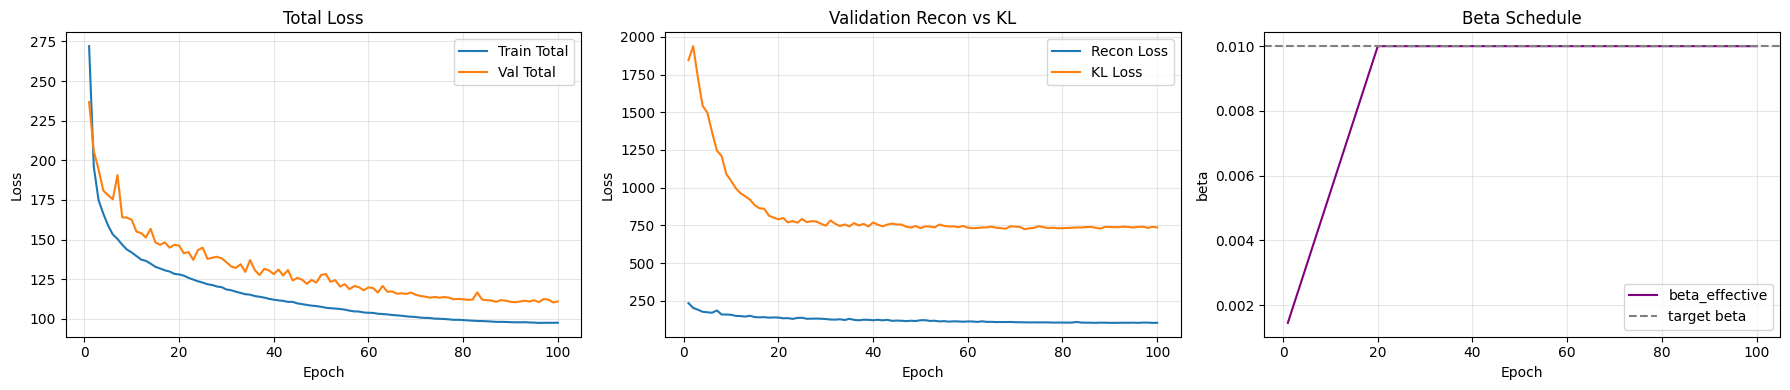

In [7]:
epochs = np.arange(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(epochs, history['train_loss'], label='Train Total')
axes[0].plot(epochs, history['val_loss'], label='Val Total')
axes[0].set_title('Total Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_recon'], label='Recon Loss')
axes[1].plot(epochs, history['val_kl'], label='KL Loss')
axes[1].set_title('Validation Recon vs KL')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

if 'beta_effective' in history:
    axes[2].plot(epochs, history['beta_effective'], color='purple', label='beta_effective')
    axes[2].axhline(config['vae']['beta'], linestyle='--', color='gray', label='target beta')
    axes[2].set_title('Beta Schedule')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('beta')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
else:
    axes[2].axis('off')

best_epoch = int(np.argmin(history['val_loss']) + 1)
print(f'Best val loss epoch: {best_epoch}')
print(f'Final val KL: {history["val_kl"][-1]:.6f}')

plt.tight_layout()
plt.show()

Using device: cuda


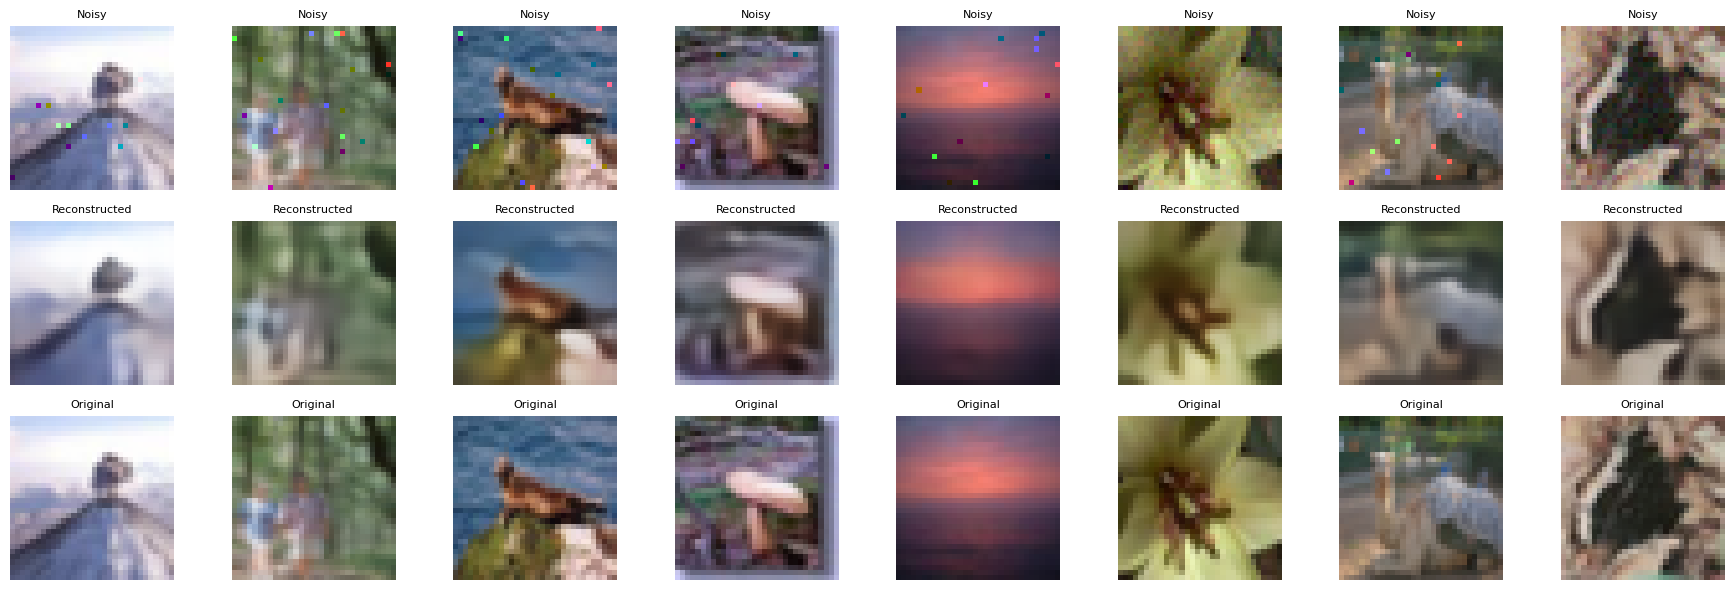

In [8]:
from src.dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
mean = config['dataset']['mean']
std = config['dataset']['std']

def denorm(batch):
    mean_t = torch.tensor(mean, dtype=batch.dtype).view(1, 3, 1, 1)
    std_t = torch.tensor(std, dtype=batch.dtype).view(1, 3, 1, 1)
    return torch.clamp(batch * std_t + mean_t, 0.0, 1.0)

_, _, test_loader = get_dataloaders(config)
noisy_norm, clean_norm, _ = next(iter(test_loader))
noisy_pixel = denorm(noisy_norm[:8])
clean_pixel = denorm(clean_norm[:8])

vae = vae.to(device).eval()
with torch.no_grad():
    recon_pixel, _, _ = vae(noisy_pixel.to(device))

fig, axes = plt.subplots(3, 8, figsize=(18, 6))
for i in range(8):
    axes[0, i].imshow(noisy_pixel[i].permute(1, 2, 0).cpu())
    axes[0, i].axis('off')
    axes[0, i].set_title('Noisy', fontsize=8)

    axes[1, i].imshow(recon_pixel[i].permute(1, 2, 0).cpu().clamp(0, 1))
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed', fontsize=8)

    axes[2, i].imshow(clean_pixel[i].permute(1, 2, 0).cpu())
    axes[2, i].axis('off')
    axes[2, i].set_title('Original', fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
from src.dataset import NoiseInjector
from src.evaluate import compute_metrics

injector = NoiseInjector()
sample = clean_pixel[0]
noise_variants = {
    'gaussian': injector.gaussian_noise(sample, std=0.08),
    'salt_pepper': injector.salt_pepper(sample, prob=0.015),
}

rows = []
with torch.no_grad():
    for noise_name, noisy_img in noise_variants.items():
        recon_img, _, _ = vae(noisy_img.unsqueeze(0).to(device))
        recon_img = recon_img.squeeze(0).cpu()
        metrics = compute_metrics(sample, recon_img)
        rows.append((noise_name, metrics['psnr'], metrics['ssim']))

print('Noise Type      PSNR (dB)    SSIM')
for noise_name, psnr, ssim in rows:
    print(f"{noise_name:<14} {psnr:>9.3f}   {ssim:>6.4f}")

# Aggregate denoising metric on a test batch.
batch_noisy, batch_clean, _ = next(iter(test_loader))
batch_noisy = denorm(batch_noisy[:64]).to(device)
batch_clean = denorm(batch_clean[:64]).to(device)
with torch.no_grad():
    batch_recon, _, _ = vae(batch_noisy)

ssim_scores = []
psnr_scores = []
for i in range(batch_clean.size(0)):
    m = compute_metrics(batch_clean[i].cpu(), batch_recon[i].cpu().clamp(0, 1))
    ssim_scores.append(m['ssim'])
    psnr_scores.append(m['psnr'])

ssim_arr = np.array(ssim_scores)
print('\nBatch Metrics (64 samples):')
print(f"Mean PSNR: {np.mean(psnr_scores):.3f} dB")
print(f"Mean SSIM: {np.mean(ssim_scores):.4f}")
print(f"SSIM >= 0.80 rate: {(ssim_arr >= 0.80).mean() * 100:.2f}%")

Noise Type      PSNR (dB)    SSIM
gaussian          28.603   0.9229
salt_pepper       29.207   0.9346

Batch Metrics (64 samples):
Mean PSNR: 26.265 dB
Mean SSIM: 0.8827
SSIM >= 0.80 rate: 93.75%


## Summary

The ConvVAE healer is configured for 32x32 CIFAR-100 images and trains on GPU when available (with CPU fallback).

| Metric | Notes |
|---|---|
| Reconstruction quality | Use PSNR and SSIM from Cell 10 |
| Optimization | AdamW + CosineAnnealingLR + early stopping |
| Target outcome | Stable denoising before classifier stage |